# **Day 13: Optimisation - From Gradient Descent to Adam**
*Module 2 - Probability, Statistics and Optimisation*

Training = solving $\min_\theta L(\theta)$. Linear regression has a closed-form solution, but logistic regression, SVMs and neural networks need **iterative optimisers**. Today we implement every important optimiser **from scratch** and watch them race.

> Optimisation is how a model finds good parameters: start somewhere, measure the error, and take small steps that reduce it. Gradient descent, momentum and Adam are different strategies for taking those steps quickly and safely.
>
> *Example:* It is like walking down a foggy hill: we cannot see the valley, but we can feel the slope under our feet and step downhill.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit      # numerically stable sigmoid 1 / (1 + exp(-z))
rng = np.random.default_rng(13)

## **1. Gradient Descent and the Learning Rate**
$$\theta_{t+1} = \theta_t - \eta\,\nabla L(\theta_t)$$
The learning rate $\eta$ is the most important hyperparameter in deep learning.

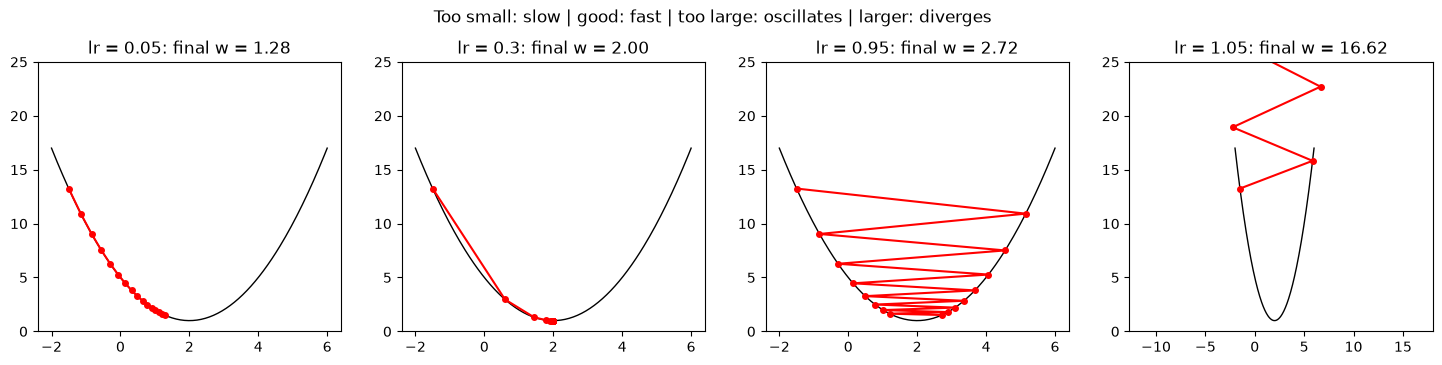

In [2]:
L = lambda w: (w - 2) ** 2 + 1
dL = lambda w: 2 * (w - 2)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
ws = np.linspace(-2, 6, 200)
for ax, lr in zip(axes, [0.05, 0.3, 0.95, 1.05]):
    w = -1.5; path = [w]
    for _ in range(15):
        w -= lr * dL(w); path.append(w)
    path = np.array(path)
    ax.plot(ws, L(ws), "k-", lw=1); ax.plot(path, L(path), "ro-", ms=4)
    ax.set_ylim(0, 25); ax.set_title(f"lr = {lr}: final w = {path[-1]:.2f}")
plt.suptitle("Too small: slow | good: fast | too large: oscillates | larger: diverges", y=1.03); plt.show()

## **2. A Real Problem: Logistic Regression**
We fit logistic regression on 2 features. Its loss (cross-entropy) is convex, so all optimisers should reach the same minimum. The question is **how fast**.

In [3]:
n = 2000
X = np.c_[rng.normal(0, 1, n), rng.normal(0, 4, n)]           # features on different scales -> ill-conditioned
w_true = np.array([2.0, -0.5])
y = (rng.random(n) < 1 / (1 + np.exp(-X @ w_true))).astype(float)

def loss_fn(w, Xb=X, yb=y):
    z = Xb @ w
    return np.mean(np.logaddexp(0, z) - yb * z)               # stable cross-entropy

def grad_fn(w, Xb=X, yb=y):
    p = expit(Xb @ w)
    return Xb.T @ (p - yb) / len(yb)

## **3. Implementing the Optimisers**

| Optimiser | Update idea |
|---|---|
| SGD | $\theta \leftarrow \theta - \eta g$ |
| Momentum | $v \leftarrow \beta v + g$; $\theta \leftarrow \theta-\eta v$ (a heavy ball rolling downhill) |
| Nesterov | Gradient at the look-ahead point $\theta - \eta\beta v$ |
| AdaGrad | Divide by $\sqrt{\sum g^2}$: per-parameter learning rates (decay too fast) |
| RMSProp | Divide by $\sqrt{\text{EMA}(g^2)}$ |
| Adam | Momentum (EMA of $g$) + RMSProp (EMA of $g^2$) + bias correction |

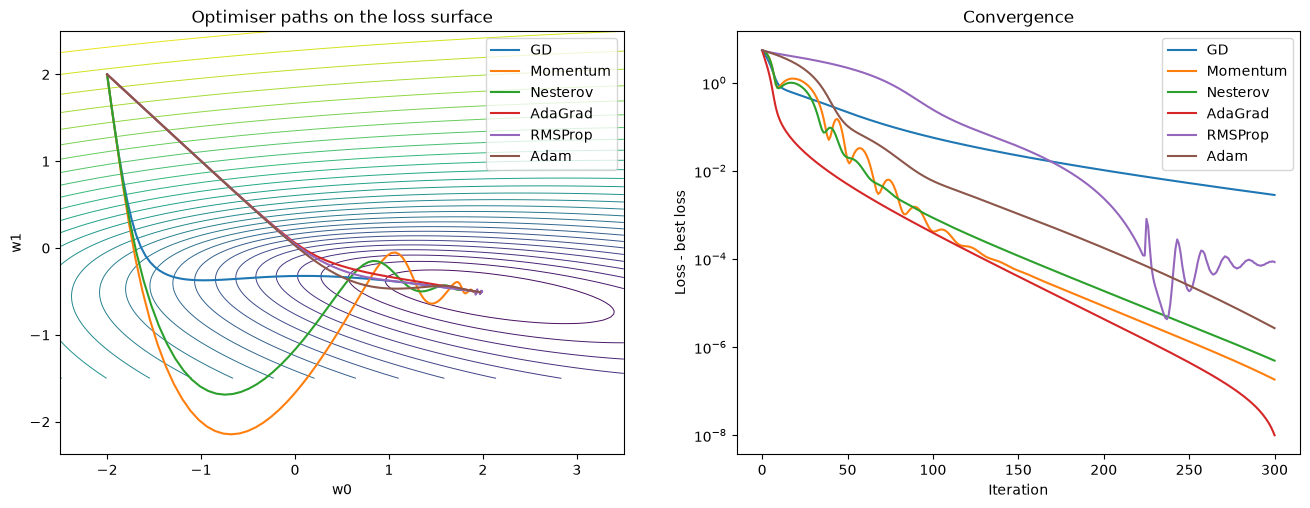

In [4]:
def optimise(method, lr, steps=300, batch=None, beta=0.9, b1=0.9, b2=0.999, eps=1e-8, seed=0):
    r = np.random.default_rng(seed)
    w = np.array([-2.0, 2.0]); v = np.zeros(2); s = np.zeros(2); path = [w.copy()]; losses = [loss_fn(w)]
    for t in range(1, steps + 1):
        if batch:
            idx = r.integers(0, n, batch); g = grad_fn(w, X[idx], y[idx])
        else:
            g = grad_fn(w)
        if method == "gd":
            w = w - lr * g
        elif method == "momentum":
            v = beta * v + g; w = w - lr * v
        elif method == "nesterov":
            g_ahead = grad_fn(w - lr * beta * v) if not batch else g
            v = beta * v + g_ahead; w = w - lr * v
        elif method == "adagrad":
            s = s + g ** 2; w = w - lr * g / (np.sqrt(s) + eps)
        elif method == "rmsprop":
            s = beta * s + (1 - beta) * g ** 2; w = w - lr * g / (np.sqrt(s) + eps)
        elif method == "adam":
            v = b1 * v + (1 - b1) * g; s = b2 * s + (1 - b2) * g ** 2
            v_hat, s_hat = v / (1 - b1 ** t), s / (1 - b2 ** t)
            w = w - lr * v_hat / (np.sqrt(s_hat) + eps)
        path.append(w.copy()); losses.append(loss_fn(w))
    return np.array(path), np.array(losses)

runs = {"GD": optimise("gd", 0.1), "Momentum": optimise("momentum", 0.03), "Nesterov": optimise("nesterov", 0.03),
        "AdaGrad": optimise("adagrad", 0.5), "RMSProp": optimise("rmsprop", 0.02), "Adam": optimise("adam", 0.05)}

W0, W1 = np.meshgrid(np.linspace(-2.5, 3.5, 120), np.linspace(-1.5, 2.5, 120))
Z = np.array([loss_fn(np.array([a, b])) for a, b in zip(W0.ravel(), W1.ravel())]).reshape(W0.shape)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].contour(W0, W1, np.log(Z), levels=30, cmap="viridis", linewidths=0.7)
for name, (path, _) in runs.items():
    axes[0].plot(path[:, 0], path[:, 1], "-", lw=1.5, label=name)
axes[0].legend(); axes[0].set_xlabel("w0"); axes[0].set_ylabel("w1"); axes[0].set_title("Optimiser paths on the loss surface")
best = min(l.min() for _, l in runs.values())
for name, (_, losses) in runs.items():
    axes[1].semilogy(losses - best + 1e-8, label=name)
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Loss - best loss"); axes[1].legend(); axes[1].set_title("Convergence")
plt.show()

- Plain GD zig-zags across the narrow valley caused by unequal feature scales (badly conditioned problem). **Feature scaling** (Day 18) helps every optimiser.
- Momentum accumulates speed along the valley; adaptive methods rescale each parameter separately.

## **4. Stochastic and Mini-Batch Gradient Descent**
Full-batch GD uses all $n$ samples per step: expensive for big data. **SGD** uses one sample, **mini-batch** uses $B$ samples (32-512 typical). Noisy steps are cheap, and the noise even helps escape saddle points and sharp minima.

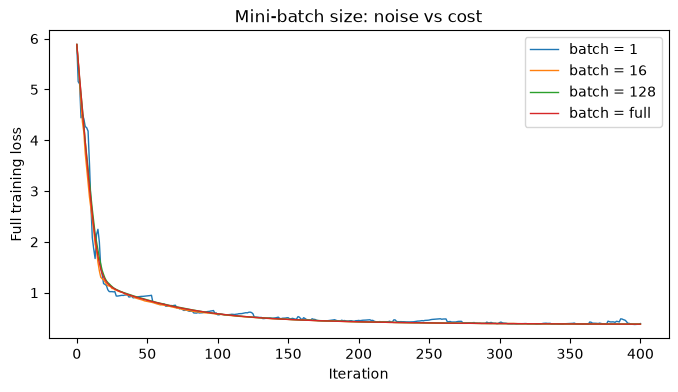

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for bs in [1, 16, 128, None]:
    _, losses = optimise("gd", 0.05, steps=400, batch=bs)
    ax.plot(losses, label=f"batch = {bs or 'full'}", lw=1)
ax.set_xlabel("Iteration"); ax.set_ylabel("Full training loss"); ax.legend(); ax.set_title("Mini-batch size: noise vs cost")
plt.show()

## **5. Learning-Rate Schedules**
Start large to move fast, end small to settle into the minimum.

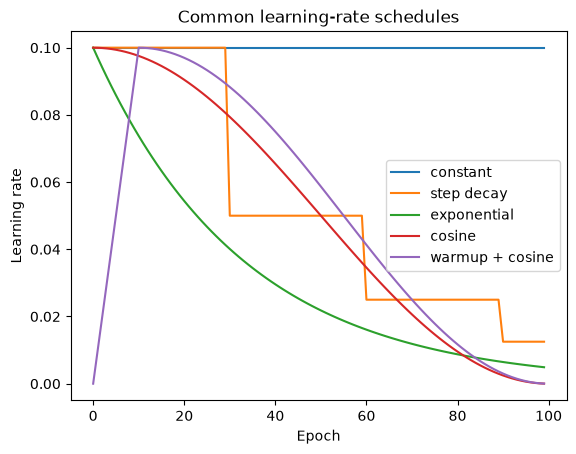

In [6]:
T = 100
schedules = {"constant": np.full(T, 0.1),
             "step decay": 0.1 * 0.5 ** (np.arange(T) // 30),
             "exponential": 0.1 * 0.97 ** np.arange(T),
             "cosine": 0.05 * (1 + np.cos(np.pi * np.arange(T) / T)),
             "warmup + cosine": np.where(np.arange(T) < 10, 0.1 * np.arange(T) / 10, 0.05 * (1 + np.cos(np.pi * (np.arange(T) - 10) / (T - 10))))}
for k, v in schedules.items():
    plt.plot(v, label=k)
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Learning rate"); plt.title("Common learning-rate schedules"); plt.show()

## **6. Non-Convex Landscapes**
Neural-network losses have many local minima and **saddle points** (gradient zero, but not a minimum). Plain GD started near a saddle moves very slowly; momentum and noise help.

In [7]:
f = lambda w: w[0] ** 2 - w[1] ** 2 + 0.1 * w[1] ** 4          # saddle at (0,0), minima at w1 = +/- 2.24
g = lambda w: np.array([2 * w[0], -2 * w[1] + 0.4 * w[1] ** 3])
for name, use_mom in [("GD", False), ("Momentum", True)]:
    w = np.array([1.0, 1e-4]); v = np.zeros(2)
    for t in range(100):
        v = 0.9 * v + g(w) if use_mom else g(w)
        w = w - 0.05 * v
    print(f"{name:<9} after 100 steps: w = {w.round(3)}, f = {f(w):.3f}")

GD        after 100 steps: w = [0.    1.192], f = -1.220
Momentum  after 100 steps: w = [0.004 2.24 ], f = -2.500


# **Part 2: Going Deeper**

### Newton's method and L-BFGS
Newton uses curvature: $\theta \leftarrow \theta - H^{-1}\nabla L$. It converges in very few steps but needs the Hessian ($d\times d$, too big for neural nets). **L-BFGS** approximates $H^{-1}$ from recent gradients; it is scikit-learn's default for `LogisticRegression`.

In [8]:
def hess_fn(w):
    p = expit(X @ w)
    return (X * (p * (1 - p))[:, None]).T @ X / n

# Pure Newton can diverge from a poor start (try w = [-2, 2]); IRLS / sklearn start at w = 0.
w = np.zeros(2); newton_losses = [loss_fn(w)]
for _ in range(8):
    w = w - np.linalg.solve(hess_fn(w), grad_fn(w)); newton_losses.append(loss_fn(w))
print("Newton losses:", np.round(newton_losses, 6))

from scipy.optimize import minimize
res = minimize(loss_fn, x0=[-2.0, 2.0], jac=grad_fn, method="L-BFGS-B")
print(f"L-BFGS: w = {res.x.round(4)} in {res.nit} iterations (true w = {w_true})")
from sklearn.linear_model import LogisticRegression
print("sklearn  :", LogisticRegression(C=np.inf, fit_intercept=False).fit(X, y).coef_.round(4))

Newton losses: [0.693147 0.422803 0.377923 0.370762 0.370468 0.370467 0.370467 0.370467
 0.370467]
L-BFGS: w = [ 1.9796 -0.5098] in 10 iterations (true w = [ 2.  -0.5])


sklearn  : [[ 1.9795 -0.5097]]


### Constrained optimisation and Lagrange multipliers
To minimise $f(\mathbf{w})$ subject to $g(\mathbf{w})=0$, solve $\nabla f = \lambda\nabla g$. Inequality constraints lead to the **KKT conditions**, which give SVMs their support vectors (Day 32), and the equivalence between Lasso's penalty and a constraint $\lVert w\rVert_1\le t$ (Day 24).

In [9]:
# minimise (w0-2)^2 + (w1-1)^2 subject to w0 + w1 = 1  -> analytical answer (1, 0)
cons = {"type": "eq", "fun": lambda w: w[0] + w[1] - 1}
r = minimize(lambda w: (w[0] - 2) ** 2 + (w[1] - 1) ** 2, [0, 0], constraints=[cons])
print("Constrained minimum:", r.x.round(4))

Constrained minimum: [1. 0.]


## **Practice Problems**
1. For GD on the logistic problem, find (by trial) the largest learning rate that still converges.
2. Standardise the columns of `X` and rerun plain GD. How many fewer iterations does it need to reach loss - best < 1e-4?
3. Implement **AdamW** (Adam with decoupled weight decay: `w -= lr * wd * w` each step).
4. *(Advanced)* Count how many Newton iterations reach a gradient norm < 1e-10. Why is it called "quadratic convergence"?

In [10]:
# Solution 1
for lr in [1, 2, 4, 6, 8]:
    _, l = optimise("gd", lr, steps=200); print(f"lr={lr}: final loss {l[-1]:.5f}")
# Solution 2
Xs = (X - X.mean(0)) / X.std(0)
def gd_iters(Xm, lr=0.5, tol=1e-4):
    w = np.array([-2.0, 2.0]); best_ = LogisticRegression(C=np.inf, fit_intercept=False).fit(Xm, y)
    target = loss_fn(best_.coef_[0], Xm, y)
    for t in range(5000):
        if loss_fn(w, Xm, y) - target < tol: return t
        w -= lr * grad_fn(w, Xm, y)
    return 5000
print("Iterations raw:", gd_iters(X, lr=0.1), "| standardised:", gd_iters(Xs, lr=0.5))
# Solution 3: AdamW
def adamw(lr=0.05, wd=0.01, steps=300, b1=0.9, b2=0.999, eps=1e-8):
    w = np.array([-2.0, 2.0]); m = np.zeros(2); s = np.zeros(2)
    for t in range(1, steps + 1):
        g = grad_fn(w)
        m = b1 * m + (1 - b1) * g; s = b2 * s + (1 - b2) * g ** 2
        w = w - lr * (m / (1 - b1 ** t)) / (np.sqrt(s / (1 - b2 ** t)) + eps) - lr * wd * w   # decoupled decay
    return w
print("AdamW weights (slightly shrunk towards 0):", adamw().round(3), "| Adam:", runs["Adam"][0][-1].round(3))
# Solution 4
w = np.zeros(2)
for it in range(1, 20):
    w = w - np.linalg.solve(hess_fn(w), grad_fn(w)); gn = np.linalg.norm(grad_fn(w))
    print(f"iter {it}: |grad| = {gn:.2e}")
    if gn < 1e-10: break

lr=1: final loss 0.37047
lr=2: final loss 0.43974
lr=4: final loss 0.66177
lr=6: final loss 1.02624
lr=8: final loss 0.97564
Iterations raw: 608 | standardised: 179
AdamW weights (slightly shrunk towards 0): [ 1.914 -0.496] | Adam: [ 1.97  -0.508]
iter 1: |grad| = 2.67e-01
iter 2: |grad| = 7.77e-02
iter 3: |grad| = 1.35e-02
iter 4: |grad| = 6.25e-04
iter 5: |grad| = 1.49e-06
iter 6: |grad| = 8.55e-12


The number of correct digits roughly doubles each Newton iteration: **quadratic convergence**.

## **Key References**
- Ruder, S. (2016). An overview of gradient descent optimization algorithms. *arXiv:1609.04747*.
- Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR 2015*.
- Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*.
- Bottou, L., Curtis, F. E., & Nocedal, J. (2018). Optimization methods for large-scale machine learning. *SIAM Review*, 60(2), 223-311.
- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.